<a href="https://colab.research.google.com/github/apurvakumbhar/Deep_Learning/blob/main/DLExperiment_01(B).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import numpy as np
import time

In [ ]:

import tensorflow as tf

# Enable eager execution
tf.config.run_functions_eagerly(True)


np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
X = np.random.rand(10000, 20)
y = np.sum(X, axis=1, keepdims=True)   # learnable target

In [ ]:

def build_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(20,)),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    return model


In [ ]:
class ConvergenceCallback(tf.keras.callbacks.Callback):
    def __init__(self, target_loss):
        super().__init__()
        self.target_loss = target_loss

    def on_epoch_end(self, epoch, logs=None):
        if logs["loss"] <= self.target_loss:
            self.model.stop_training = True

In [ ]:
def measure_convergence_time(optimizer, target_loss):
    model = build_model()
    model.compile(
        optimizer=optimizer,
        loss="mse"
    )

    callback = ConvergenceCallback(target_loss)

    start_time = time.time()

    history = model.fit(
        X, y,
        epochs=200,
        batch_size=32,
        verbose=0,
        callbacks=[callback]
    )

    end_time = time.time()

    # Return everything as before, plus 'history' for plotting
    return {
        "time": end_time - start_time,
        "epochs": len(history.history["loss"]),
        "final_loss": history.history["loss"][-1],
        "history": history.history["loss"]  # ✅ add this line
    }

In [ ]:

sgd = SGD(learning_rate=0.01)

sgd_result = measure_convergence_time(
    optimizer=sgd,
    target_loss=0.01
)

In [ ]:
sgd_momentum = SGD(
    learning_rate=0.01,
    momentum=0.9
)

sgd_momentum_result = measure_convergence_time(
    optimizer=sgd_momentum,
    target_loss=0.01

)


===== CONVERGENCE RESULTS =====

SGD:
  Time to converge   : 70.28 sec
  Epochs to converge : 12
  Final loss         : 0.009132

SGD with Momentum:
  Time to converge   : 21.35 sec
  Epochs to converge : 3
  Final loss         : 0.003310



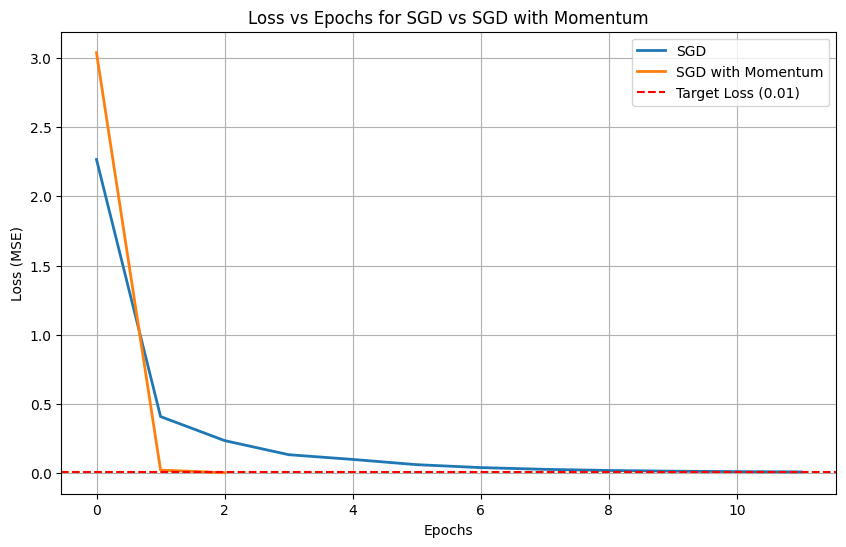

In [ ]:



import matplotlib.pyplot as plt

# Print convergence results
print("===== CONVERGENCE RESULTS =====\n")

print("SGD:")
print(f"  Time to converge   : {sgd_result['time']:.2f} sec")
print(f"  Epochs to converge : {sgd_result['epochs']}")
print(f"  Final loss         : {sgd_result['final_loss']:.6f}\n")

print("SGD with Momentum:")
print(f"  Time to converge   : {sgd_momentum_result['time']:.2f} sec")
print(f"  Epochs to converge : {sgd_momentum_result['epochs']}")
print(f"  Final loss         : {sgd_momentum_result['final_loss']:.6f}\n")

# Plot Loss vs Epoch
plt.figure(figsize=(10,6))
plt.plot(sgd_result['history'], label="SGD", linewidth=2)
plt.plot(sgd_momentum_result['history'], label="SGD with Momentum", linewidth=2)
plt.axhline(y=0.01, color='r', linestyle='--', label='Target Loss (0.01)')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Epochs for SGD vs SGD with Momentum")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Nesterov Accelerated Gradient optimizer
nag = SGD(
    learning_rate=0.01,
    momentum=0.9,
    nesterov=True
)

nag_result = measure_convergence_time(
    optimizer=nag,
    target_loss=0.01

)


In [ ]:
print("Nesterov Accelerated Gradient (NAG):")
print(f"  Time to converge   : {nag_result['time']:.2f} sec")
print(f"  Epochs to converge : {nag_result['epochs']}")
print(f"  Final loss         : {nag_result['final_loss']:.6f}")


Nesterov Accelerated Gradient (NAG):
  Time to converge   : 15.96 sec
  Epochs to converge : 2
  Final loss         : 0.002024


In [ ]:
from tensorflow.keras.optimizers import Adagrad

# Create Adagrad optimizer
adagrad = Adagrad(
    learning_rate=0.01
)

# Measure convergence time
adagrad_result = measure_convergence_time(
    optimizer=adagrad,
    target_loss=0.01
)


In [ ]:
print("Adagrad Optimizer:")
print(f"  Time to converge   : {adagrad_result['time']:.2f} sec")
print(f"  Epochs to converge : {adagrad_result['epochs']}")
print(f"  Final loss         : {adagrad_result['final_loss']:.6f}")

Adagrad Optimizer:
  Time to converge   : 54.16 sec
  Epochs to converge : 7
  Final loss         : 0.008819


In [ ]:
from tensorflow.keras.optimizers import RMSprop

# Create RMSProp optimizer
rmsprop = RMSprop(
    learning_rate=0.0001
)

# Measure convergence time
rmsprop_result = measure_convergence_time(
    optimizer=rmsprop,
    target_loss=0.01
)

In [ ]:
print("RMSProp Optimizer:")
print(f"  Time to converge   : {rmsprop_result['time']:.2f} sec")
print(f"  Epochs to converge : {rmsprop_result['epochs']}")
print(f"  Final loss         : {rmsprop_result['final_loss']:.6f}")

RMSProp Optimizer:
  Time to converge   : 43.70 sec
  Epochs to converge : 5
  Final loss         : 0.009051


In [ ]:
from tensorflow.keras.optimizers import Adam

# Create Adam optimizer
adam = Adam(
    learning_rate=0.01
)

# Measure convergence time
adam_result = measure_convergence_time(
    optimizer=adam,
    target_loss=0.01
)

In [ ]:
print("Adam Optimizer:")
print(f"  Time to converge   : {adam_result['time']:.2f} sec")
print(f"  Epochs to converge : {adam_result['epochs']}")
print(f"  Final loss         : {adam_result['final_loss']:.6f}")

Adam Optimizer:
  Time to converge   : 24.47 sec
  Epochs to converge : 2
  Final loss         : 0.005052


In [ ]:
from tensorflow.keras.optimizers import SGD, Adam, Adagrad, RMSprop

optimizers = {
    "SGD": SGD(learning_rate=0.01),
    "SGD with Momentum": SGD(learning_rate=0.01, momentum=0.9),
    "NAG": SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    "Adagrad": Adagrad(learning_rate=0.01),
    "Adam": Adam(learning_rate=0.01),
    "RMSProp": RMSprop(learning_rate=0.0001)
}

In [ ]:

results = {}

for name, opt in optimizers.items():
    print(f"Running {name}...")
    results[name] = measure_convergence_time(
        optimizer=opt,
        target_loss=0.01
    )

Running SGD...
Running SGD with Momentum...
Running NAG...
Running Adagrad...
Running Adam...
Running RMSProp...


In [ ]:
print("\n===== CONVERGENCE RESULTS (All Optimizers) =====")
print(f"{'Optimizer':25s} {'Time (s)':>10s} {'Epochs':>10s} {'Final Loss':>12s}")
print("-"*60)

for name, res in results.items():
    print(f"{name:25s} {res['time']:10.2f} {res['epochs']:10d} {res['final_loss']:12.6f}")

#RMSProp may need learning rate tuning to perform well in this dataset



===== CONVERGENCE RESULTS (All Optimizers) =====
Optimizer                   Time (s)     Epochs   Final Loss
------------------------------------------------------------
SGD                            70.61         12     0.008536
SGD with Momentum              17.50          2     0.000617
NAG                            47.84          6     0.008619
Adagrad                        29.72          4     0.009248
Adam                           24.21          2     0.002863
RMSProp                        51.87          6     0.005242
